In [ ]:
# 넘파이 버전이 1.~ 이어야 prophet이 돌아갑니다
import numpy as np
print(np.__version__)

# 만약 아니라면 가상환경 설정해서 아래 코드 이용하여 추천!
# !pip install numpy==1.26.4

# 다시 확인
# print(np.__version__)

# prophet 다운
# !pip install prophet

1.26.4


# 사계절 가성비 수트셋업

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import platform
import datetime
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
def set_matplotlib_font():
    system = platform.system()

    if system == "Windows":
        plt.rc('font', family='Malgun Gothic')
    elif system == "Darwin":  # macOS
        plt.rc('font', family='AppleGothic')
    elif system == "Linux":
        plt.rc('font', family='NanumGothic')
    else:
        print("Unknown system. Please set font manually.")

    plt.rcParams['axes.unicode_minus'] = False

# 폰트 설정 함수 호출
set_matplotlib_font()


#데이터 불러오기 
df = pd.read_csv('./data/model_df_new_cat_음수할인율처리후.csv')
print(df.columns)
df.head(1)

Index(['기획년도', '주차', '카테고리_통합', '시즌이월', '시즌', '총입고수량', '판매수량', '판매액', '평균택가',
       '평균원가', '주차별_평균_실판매가', '월별_평균_실판매가', '시즌별_평균_실판매가', '총입고원가', '총입고택가',
       '매출원가계', '판매택가계', '실판매가', '할인율', '누적판매수량', '누적판매액', '누적매출원가', '누적판매택가',
       '누적판매율', 'ROI', '악천후일수', '평균기온(도)'],
      dtype='object')


,기획년도,주차,카테고리_통합,시즌이월,시즌,총입고수량,판매수량,판매액,평균택가,평균원가,...,실판매가,할인율,누적판매수량,누적판매액,누적매출원가,누적판매택가,누적판매율,ROI,악천후일수,평균기온(도)
0,2021,2021-07-11,가을_가성비 수트셋업,01_시즌,가을,13163,496,84636400,184000,28105,...,170638,7,496,84636400,13940080,91264000,3.77,0.17,0,28.5


In [10]:
# 사계절_가성비수트셋업만 골라서 주차별 판매수량 합치기
suitset_four = df[df['카테고리_통합']=='사계절_가성비 수트셋업']
# suitset_four['판매수량'].plot(figsize=(20,6)) # 판매수량 시각화

# Prophet에 사용할 데이터프레임 생성
suitset_four_df = suitset_four[['주차', '판매수량', '할인율','악천후일수','총입고수량']].rename(columns={'주차': 'ds', '판매수량': 'y'})
suitset_four_df

,ds,y,할인율,악천후일수,총입고수량
1814,2021-01-03,1069,38,0,18518
1815,2021-01-10,1034,34,0,35676
1816,2021-01-17,1290,35,0,49009
1817,2021-01-24,1257,42,0,49009
1818,2021-01-31,1806,44,0,49009
...,...,...,...,...,...
2018,2024-12-01,568,50,0,63577
2019,2024-12-08,800,56,0,63577
2020,2024-12-15,554,54,0,63577
2021,2024-12-22,444,55,0,63577


In [11]:
# ds가 datetime 맞는지 확인
# suitset_four_df.info()
# datetime 변환
suitset_four_df['ds'] = pd.to_datetime(suitset_four_df['ds'])
print(suitset_four_df.dtypes)

ds       datetime64[ns]
y                 int64
할인율               int64
악천후일수             int64
총입고수량             int64
dtype: object


<Axes: xlabel='ds'>

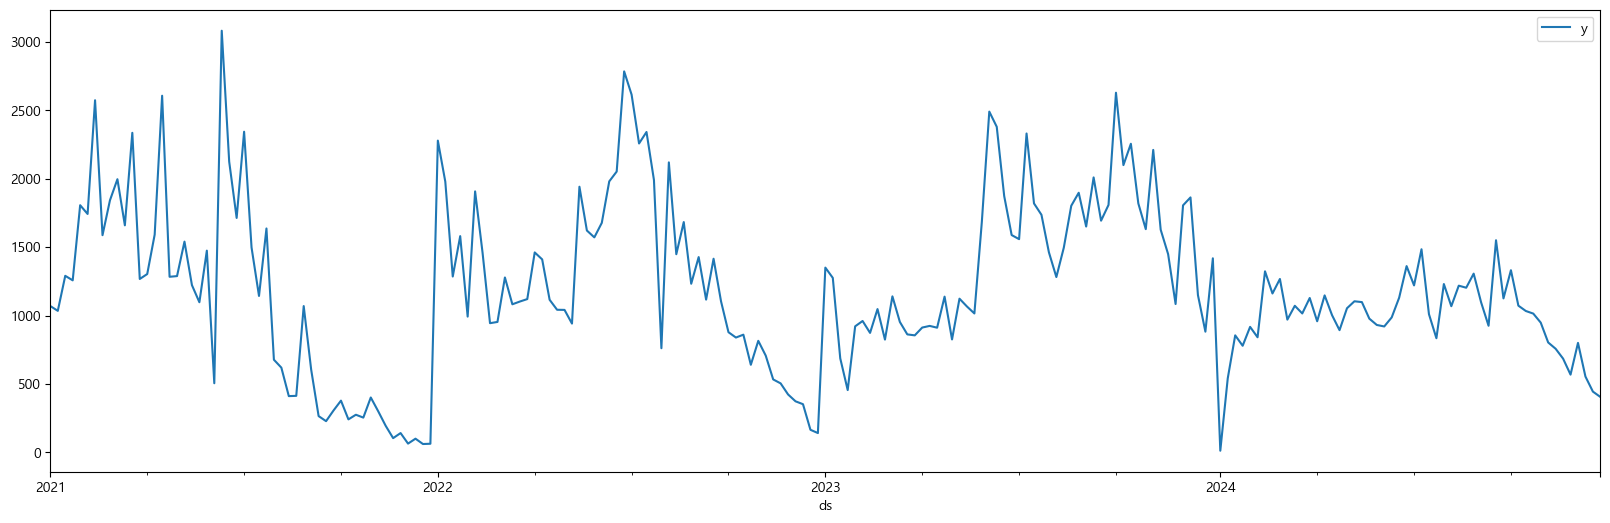

In [12]:
# 4년치 매출수량 시각화, 봄/가을에 판매량이 높고 연말에 떨어지는 추이
suitset_four_df.plot(x='ds', y='y', figsize=(20,6))

## 모델 학습 및 예측

In [13]:
# 데이터 분할
# 전체 데이터의 길이 확인
total_len = len(suitset_four_df)
# 훈련 데이터 (2021~2023년)
train_data = suitset_four_df[(suitset_four_df['ds'].dt.year >= 2021) & (suitset_four_df['ds'].dt.year <= 2023)]
# 평가 데이터 (2024년)
test_data = suitset_four_df[suitset_four_df['ds'].dt.year == 2024]

# 데이터 길이 확인
print(total_len, len(train_data), len(test_data))

209 157 52


In [14]:
from prophet import Prophet
from prophet.plot import plot_plotly

m = Prophet(
    changepoint_prior_scale=0.1,
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)

# 외생 변수 추가
m.add_regressor('할인율')
m.add_regressor('악천후일수')

# 모델 학습
m.fit(train_data)

21:12:10 - cmdstanpy - INFO - Chain [1] start processing
21:12:10 - cmdstanpy - INFO - Chain [1] done processing


In [15]:
# 주차 기준으로 미래 데이터프레임 생성 (기존 데이터 개수만큼 예측 연습)
future = suitset_four_df[['ds', '할인율', '악천후일수']].copy()

# future 데이터프레임 생성 (train + test 기간만큼 예측 확장)
future = suitset_four_df[['ds', '할인율', '악천후일수']].copy()
future = pd.concat([future, test_data[['ds', '할인율', '악천후일수']]], ignore_index=True)

# 예측실행
forecast = m.predict(future)

forecast_result = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

# 테스트 데이터의 실제값과 예측값 merge
test_result = test_data[['ds', 'y']].merge(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds', how='left')

## 시각화 및 성능평가(CPS 바꿔가면서)

21:12:11 - cmdstanpy - INFO - Chain [1] start processing
21:12:11 - cmdstanpy - INFO - Chain [1] done processing


입고비율 (2024 / 2023): 0.53

🔹 Testing changepoint_prior_scale = 0.001...

🔹 Testing changepoint_prior_scale = 0.01...


21:12:11 - cmdstanpy - INFO - Chain [1] start processing
21:12:11 - cmdstanpy - INFO - Chain [1] done processing
21:12:11 - cmdstanpy - INFO - Chain [1] start processing



🔹 Testing changepoint_prior_scale = 0.05...


21:12:11 - cmdstanpy - INFO - Chain [1] done processing
21:12:11 - cmdstanpy - INFO - Chain [1] start processing
21:12:11 - cmdstanpy - INFO - Chain [1] done processing


...


🔹 Testing changepoint_prior_scale = 5.0...


21:12:12 - cmdstanpy - INFO - Chain [1] done processing
21:12:12 - cmdstanpy - INFO - Chain [1] start processing



🔹 Testing changepoint_prior_scale = 10.0...


21:12:13 - cmdstanpy - INFO - Chain [1] done processing



최적 changepoint_prior_scale (MSE 기준): 0.01
최적 모델 MSE: 58134.625294262805

CPS 성능 비교 결과:
      CPS            MSE        RMSE
1   0.010   58134.625294  241.111230
3   0.100   61246.618717  247.480542
2   0.050   64150.781807  253.280046
0   0.001   76948.161091  277.395316
6   5.000   79101.755565  281.250343
7  10.000  114700.100527  338.674033
4   0.500  772045.948014  878.661452
5   1.000  901659.464179  949.557510


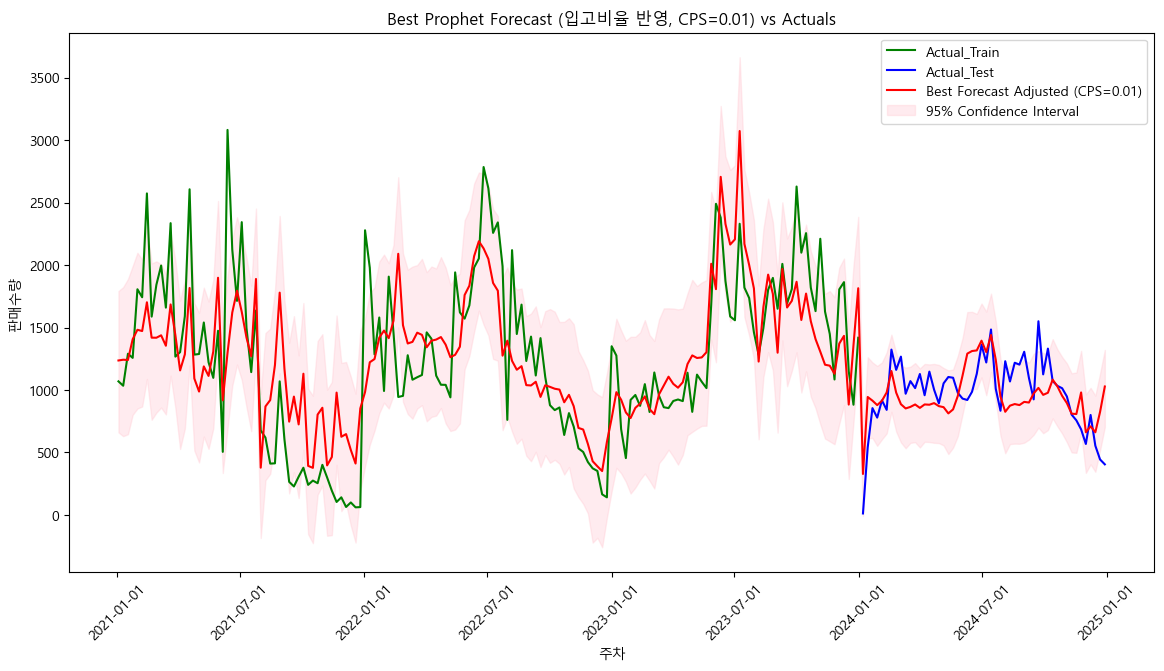

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_squared_error

# 입고비율 계산
총입고_2023 = suitset_four_df.loc[suitset_four_df['ds'].dt.year == 2023, '총입고수량'].iloc[-1]
입고계획량_2024 = suitset_four_df.loc[suitset_four_df['ds'].dt.year == 2024, '총입고수량'].iloc[-1]
입고비율 = 입고계획량_2024 / 총입고_2023
print(f"입고비율 (2024 / 2023): {입고비율:.2f}")

cps_values = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]
best_cps = None
best_mse = float('inf')
best_forecast = None
results = []

def get_metrics_with_scale(test_merged, 입고비율):
    test_merged['yhat_adjusted'] = test_merged['yhat']
    test_merged.loc[test_merged['ds'].dt.year == 2024, 'yhat_adjusted'] *= 입고비율
    mse = mean_squared_error(test_merged['y'], test_merged['yhat_adjusted'])
    rmse = np.sqrt(mse)
    return mse, rmse

for cps in cps_values:
    print(f"\n🔹 Testing changepoint_prior_scale = {cps}...")

    m = Prophet(
        changepoint_prior_scale=cps,
        yearly_seasonality=True,
        seasonality_mode='multiplicative'
    )
    m.add_regressor('할인율')
    m.add_regressor('악천후일수')
    m.fit(train_data)

    future = suitset_four_df[['ds', '할인율', '악천후일수']].copy()
    forecast = m.predict(future)

    merged_data = pd.merge(suitset_four_df[['ds', 'y']], forecast[['ds', 'yhat']], on='ds', how='inner')
    test_merged = merged_data[merged_data['ds'].isin(test_data['ds'])]

    mse, rmse = get_metrics_with_scale(test_merged, 입고비율)
    results.append((cps, mse, rmse, forecast))

    if mse < best_mse:
        best_mse = mse
        best_cps = cps
        best_forecast = forecast

# 결과 정리 및 출력
results_df = pd.DataFrame(results, columns=["CPS", "MSE", "RMSE", "Forecast"])
results_df.sort_values(by="MSE", inplace=True)

print("\n최적 changepoint_prior_scale (MSE 기준):", best_cps)
print("최적 모델 MSE:", best_mse)
print("\nCPS 성능 비교 결과:")
print(results_df.drop(columns=["Forecast"]))

# best_forecast에 입고비율 보정 및 신뢰구간까지 추가
best_forecast['yhat_adjusted'] = best_forecast['yhat']
best_forecast.loc[best_forecast['ds'].dt.year == 2024, 'yhat_adjusted'] *= 입고비율

best_forecast['yhat_lower_adjusted'] = best_forecast['yhat_lower']
best_forecast['yhat_upper_adjusted'] = best_forecast['yhat_upper']
best_forecast.loc[best_forecast['ds'].dt.year == 2024, ['yhat_lower_adjusted', 'yhat_upper_adjusted']] *= 입고비율

# 최적 모델 시각화
plt.figure(figsize=(14, 7))
plt.plot(train_data['ds'], train_data['y'], label='Actual_Train', color='green')
plt.plot(test_data['ds'], test_data['y'], label='Actual_Test', color='blue')
plt.plot(best_forecast['ds'], best_forecast['yhat_adjusted'], label=f'Best Forecast Adjusted (CPS={best_cps})', color='red')

plt.fill_between(best_forecast['ds'], best_forecast['yhat_lower_adjusted'], best_forecast['yhat_upper_adjusted'],
                 color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title(f'Best Prophet Forecast (입고비율 반영, CPS={best_cps}) vs Actuals')
plt.xlabel('주차')
plt.ylabel('판매수량')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()

## 잔차분석

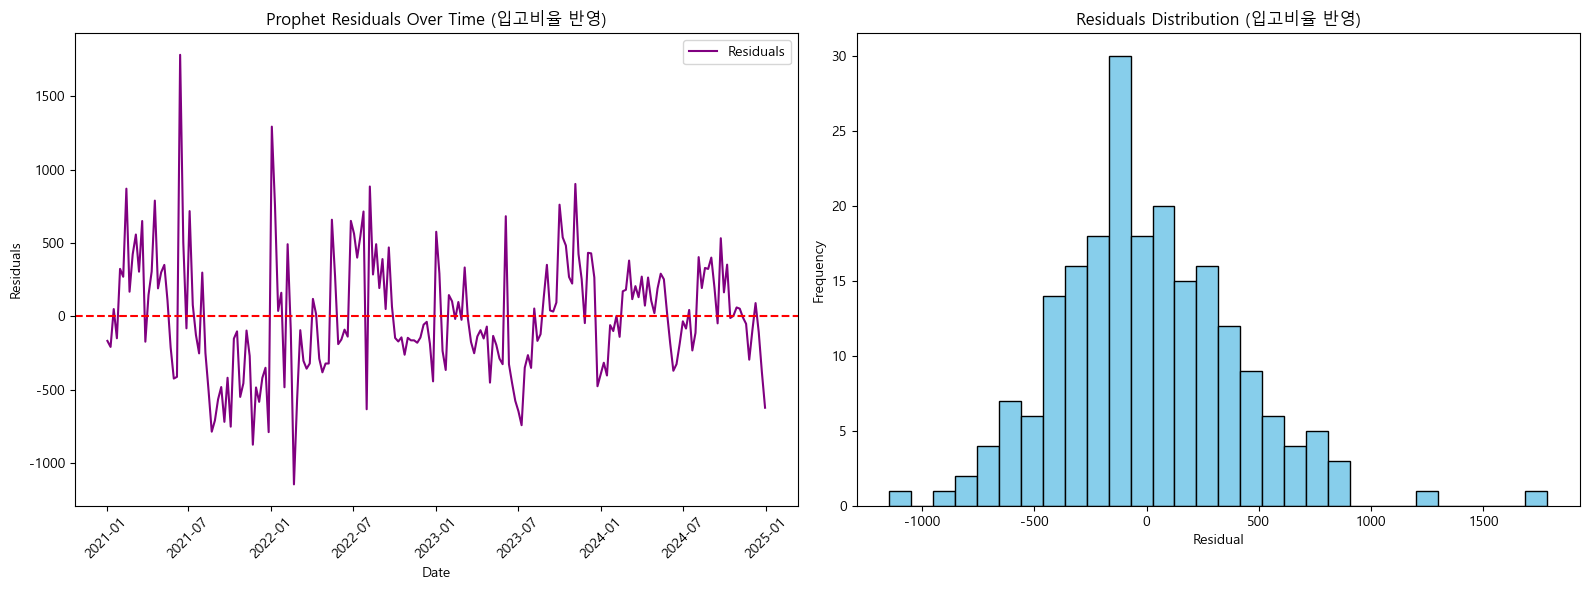


Ljung-Box Test Result:
       lb_stat     lb_pvalue
10  104.132534  8.089441e-18


In [17]:
# 보정된 예측값으로 실제와 병합
merged_data = pd.merge(suitset_four_df[['ds', 'y']], best_forecast[['ds', 'yhat_adjusted']], on='ds', how='inner')

# 잔차 계산
merged_data['residual'] = merged_data['y'] - merged_data['yhat_adjusted']

# 서브플롯 생성 (잔차 시계열 + 히스토그램)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (왼쪽) 잔차 시계열 그래프
axes[0].plot(merged_data['ds'], merged_data['residual'], label='Residuals', color='purple')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Prophet Residuals Over Time (입고비율 반영)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residuals')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# (오른쪽) 잔차 히스토그램
axes[1].hist(merged_data['residual'], bins=30, color='skyblue', edgecolor='black')
axes[1].set_title('Residuals Distribution (입고비율 반영)')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Ljung-Box 테스트 (잔차의 랜덤성 검정)
from statsmodels.stats.diagnostic import acorr_ljungbox
ljung_test = acorr_ljungbox(merged_data['residual'], lags=[10], return_df=True)
print("\nLjung-Box Test Result:")
print(ljung_test)
